In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from urllib.parse import quote

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12

In [2]:
def nea_tap_query(query: str) -> pd.DataFrame:
    """
    Run a TAP query against the NASA Exoplanet Archive and return a pandas DataFrame.
    """
    base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    url = f"{base}?query={quote(query)}&format=csv"
    return pd.read_csv(url)

In [3]:
kepler_query = """
SELECT
    kepid,
    tm_designation,
    ra,
    dec,
    teff,
    teff_err1,
    teff_err2,
    radius,
    radius_err1,
    radius_err2,
    mass,
    mass_err1,
    mass_err2
FROM keplerstellar
WHERE teff IS NOT NULL
  AND radius IS NOT NULL
  AND mass IS NOT NULL
"""

kepler_stars = nea_tap_query(kepler_query)

print("Kepler stellar sample size:", len(kepler_stars))
print(kepler_stars.head())
print(kepler_stars.columns.tolist())

Kepler stellar sample size: 787129
     kepid           tm_designation         ra        dec  teff  teff_err1  \
0  9770862  2MASS J19274858+4630098  291.95245  46.502739  5910      157.0   
1  9770895  2MASS J19275096+4630422  291.96234  46.511730  5101      155.0   
2  9770983  2MASS J19275843+4630578  291.99350  46.516071  5977      157.0   
3  9770992  2MASS J19275926+4631114  291.99692  46.519852  4904      107.0   
4  9771031  2MASS J19280394+4630130  292.01642  46.503632  4860       80.0   

   teff_err2  radius  radius_err1  radius_err2    mass  mass_err1  mass_err2  
0     -163.0   1.050        0.369       -0.151  0.9374     0.1394    -0.0941  
1     -140.0   0.668        0.093       -0.053  0.6785     0.0898    -0.0471  
2     -232.0   1.022        0.374       -0.087  1.1327     0.1837    -0.1446  
3     -145.0  11.723        4.047       -5.002  2.0001     0.8146    -0.9773  
4     -185.0  13.574        0.474       -4.457  3.1402     0.1718    -1.7093  
['kepid', 'tm_designat

In [6]:
schema_query = """
SELECT column_name
FROM TAP_SCHEMA.columns
WHERE table_name = 'pscomppars'
ORDER BY column_name
"""

ps_cols = nea_tap_query(schema_query)
print(ps_cols.head(50))
print(ps_cols["column_name"].tolist())

          column_name
0            ast_flag
1             cb_flag
2                 dec
3              decstr
4       disc_facility
5     disc_instrument
6         disc_locale
7        disc_pubdate
8        disc_refname
9      disc_telescope
10          disc_year
11    discoverymethod
12          dkin_flag
13               elat
14               elon
15           etv_flag
16        gaia_dr2_id
17        gaia_dr3_id
18               glat
19               glon
20            hd_name
21           hip_name
22           hostname
23              htm20
24           ima_flag
25         micro_flag
26           obm_flag
27          pl_angsep
28  pl_angsep_reflink
29      pl_angseperr1
30      pl_angseperr2
31       pl_angseplim
32       pl_angsepstr
33          pl_bmasse
34  pl_bmasse_reflink
35      pl_bmasseerr1
36      pl_bmasseerr2
37       pl_bmasselim
38       pl_bmassestr
39          pl_bmassj
40  pl_bmassj_reflink
41      pl_bmassjerr1
42      pl_bmassjerr2
43       pl_bmassjlim
44       p

In [7]:
sample_query = """
SELECT
    pl_name,
    hostname,
    gaia_dr2_id,
    gaia_dr3_id,
    tic_id,
    tran_flag,
    pl_orbincl,
    pl_orbinclerr1,
    pl_orbinclerr2,
    st_teff,
    st_tefferr1,
    st_tefferr2,
    st_rad,
    st_raderr1,
    st_raderr2,
    st_mass,
    st_masserr1,
    st_masserr2,
    st_vsin,
    st_vsinerr1,
    st_vsinerr2,
    sy_kepmag
FROM pscomppars
WHERE tran_flag = 1
  AND pl_orbincl IS NOT NULL
  AND st_teff IS NOT NULL
  AND st_rad IS NOT NULL
  AND st_vsin IS NOT NULL
"""

sample = nea_tap_query(sample_query)
print("Raw planet-host sample:", len(sample))
print(sample.head())
print(sample.columns.tolist())

Raw planet-host sample: 1248
      pl_name  hostname                   gaia_dr2_id  \
0     K2-10 b     K2-10  Gaia DR2 3798690151434945280   
1   CoRoT-3 b   CoRoT-3  Gaia DR2 4263427117767106816   
2   HD 3167 b   HD 3167  Gaia DR2 2554032474712538880   
3  CoRoT-17 b  CoRoT-17  Gaia DR2 4255957040079935488   
4   HD 3167 c   HD 3167  Gaia DR2 2554032474712538880   

                    gaia_dr3_id         tic_id  tran_flag  pl_orbincl  \
0  Gaia DR3 3798690151434945280  TIC 363573185          1    89.50414   
1  Gaia DR3 4263427117767106816  TIC 392353449          1    85.90000   
2  Gaia DR3 2554032474712538880  TIC 318707987          1    83.40000   
3  Gaia DR3 4255957040079935488  TIC 218299312          1    88.34000   
4  Gaia DR3 2554032474712538880  TIC 318707987          1    89.30000   

   pl_orbinclerr1  pl_orbinclerr2  st_teff  ...  st_rad  st_raderr1  \
0         0.35078        -0.52796   5533.0  ...   0.956       0.037   
1         0.80000        -0.80000   6740.0  ...

In [16]:
hosts = (
    sample.sort_values("pl_name")
    .drop_duplicates(subset=["hostname"])
    .copy()
)

print("Unique host stars:", len(hosts))

Unique host stars: 981


In [17]:
# Start from the unique host-star table
hosts = hosts.copy()

# ------------------------------
# Basic finite-value requirements
# ------------------------------
needed_cols = [
    "pl_orbincl",
    "st_teff",
    "st_rad",
    "st_vsin"
]

# For Step 5 / angular momentum, also require mass
if "st_mass" in hosts.columns:
    needed_cols.append("st_mass")

for col in needed_cols:
    hosts = hosts[hosts[col].notna()]

# ------------------------------
# Physical parameter cuts
# ------------------------------
# Inclination must be physical
hosts = hosts[(hosts["pl_orbincl"] > 0) & (hosts["pl_orbincl"] < 180)].copy()

# Stellar parameters must be positive
hosts = hosts[(hosts["st_rad"] > 0) & (hosts["st_vsin"] > 0) & (hosts["st_teff"] > 0)].copy()

if "st_mass" in hosts.columns:
    hosts = hosts[hosts["st_mass"] > 0].copy()

# ------------------------------
# Inclination correction
# ------------------------------
hosts["i_planet_rad"] = np.deg2rad(hosts["pl_orbincl"])
hosts["sin_i"] = np.sin(hosts["i_planet_rad"])

# Avoid pathological deprojection
# sin(i) > 0.2 corresponds to i roughly between 11.5 and 168.5 deg
hosts = hosts[hosts["sin_i"] > 0.2].copy()

# ------------------------------
# Derived quantities
# ------------------------------
hosts["vrot_kms"] = hosts["st_vsin"] / hosts["sin_i"]

Rsun_km = 6.957e5
sec_per_day = 86400.0

hosts["Rstar_km"] = hosts["st_rad"] * Rsun_km
hosts["Prot_days"] = (2.0 * np.pi * hosts["Rstar_km"] / hosts["vrot_kms"]) / sec_per_day

# ------------------------------
# Sanity cuts on derived values
# ------------------------------
# Remove obviously pathological outliers before fitting/plotting
hosts = hosts[(hosts["vrot_kms"] > 0) & (hosts["vrot_kms"] < 200)].copy()
hosts = hosts[(hosts["Prot_days"] > 0.05) & (hosts["Prot_days"] < 100)].copy()

# Optional: trim clearly extreme Teff values if desired
hosts = hosts[(hosts["st_teff"] > 2500) & (hosts["st_teff"] < 12000)].copy()

print("Final cleaned host sample:", len(hosts))
print(hosts[["hostname", "st_teff", "st_vsin", "pl_orbincl", "vrot_kms", "Prot_days"]].head())

Final cleaned host sample: 947
         hostname  st_teff  st_vsin  pl_orbincl   vrot_kms  Prot_days
960        55 Cnc   5172.0     1.23       83.59   1.237738  38.545277
298        AU Mic   3540.0     9.20       88.39   9.203633   4.738448
772     BD+20 594   5766.0     3.30       89.55   3.300102  16.557111
818  BD-14 3065 A   6935.0    22.00       80.78  22.287952   5.334403
226       CoRoT-1   5950.0     5.20       85.10   5.219074  10.760133


In [18]:
hosts["vrot_kms"] = hosts["st_vsin"] / np.sin(hosts["i_planet_rad"])

In [19]:
Rsun_km = 6.957e5
sec_per_day = 86400.0

hosts["Rstar_km"] = hosts["st_rad"] * Rsun_km
hosts["Prot_days"] = (2.0 * np.pi * hosts["Rstar_km"] / hosts["vrot_kms"]) / sec_per_day

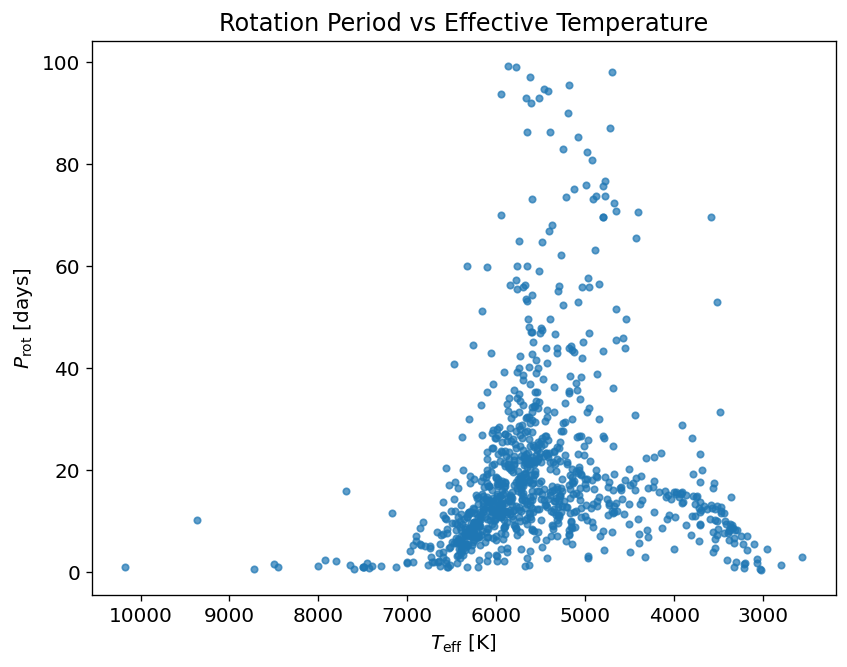

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(hosts["st_teff"], hosts["Prot_days"], s=15, alpha=0.7)
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel(r"$P_{\rm rot}$ [days]")
plt.title("Rotation Period vs Effective Temperature")
plt.gca().invert_xaxis()  # conventional stellar plotting choice
plt.show()

In [21]:
Msun_kg = 1.98847e30
Rsun_m = 6.957e8

hosts = hosts[hosts["st_mass"].notna()].copy()

hosts["Mstar_kg"] = hosts["st_mass"] * Msun_kg
hosts["Rstar_m"] = hosts["st_rad"] * Rsun_m
hosts["vrot_m_s"] = hosts["vrot_kms"] * 1000.0

hosts["Lstar"] = (2.0 / 5.0) * hosts["Mstar_kg"] * hosts["Rstar_m"] * hosts["vrot_m_s"]

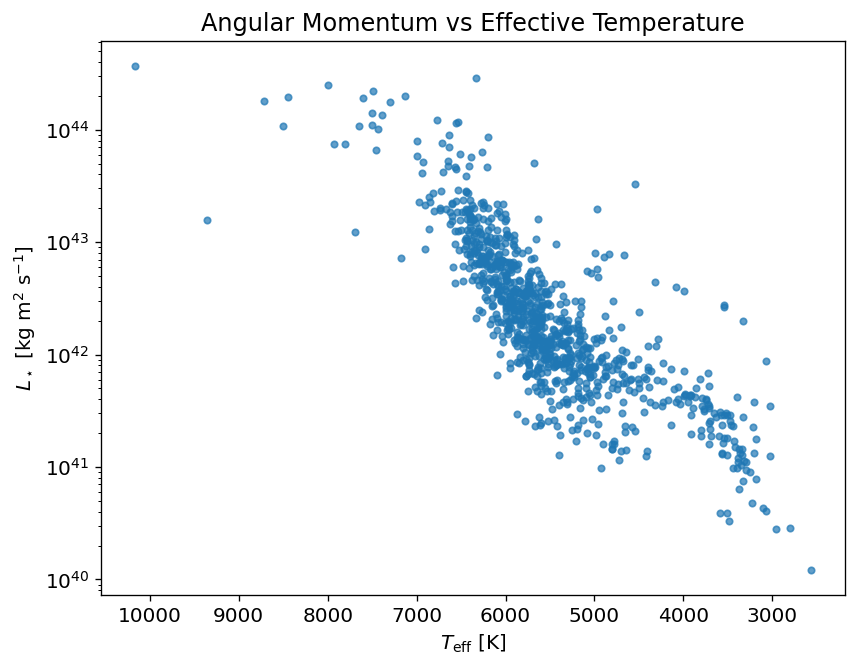

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(hosts["st_teff"], hosts["Lstar"], s=15, alpha=0.7)
plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel(r"$L_\star$ [kg m$^2$ s$^{-1}$]")
plt.title("Angular Momentum vs Effective Temperature")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.show()

In [35]:
from astropy.io import fits

fits.info("allStarLite-dr17.fits")

Filename: allStarLite-dr17.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    399   733901R x 191C   [30A, 6A, 20A, 30A, D, D, D, D, E, E, E, E, E, E, E, 32A, E, E, J, J, J, J, J, J, 132A, 32A, 32A, J, E, E, K, 132A, K, 132A, E, E, E, E, E, E, E, E, E, E, E, J, J, E, E, E, E, E, E, K, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, 8A, E, 9K, K, 256A, E, E, E, 27E, 27E, 27E, 27E, 27E, 27E, J, K, 10A, 27E, 27E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J, E, E, E, J]   
  2                1 ImageHDU         6   (360,)   int64   
  3                1 BinTableHDU     26   1R x 6C   [7514E, 576A, 540A, 27J, 1296A, 420A]   
  4                1 

In [36]:
with fits.open("allStarLite-dr17.fits", memmap=True) as hdul:
    print(hdul[1].columns.names)

['APOGEE_ID', 'TELESCOPE', 'FIELD', 'ALT_ID', 'RA', 'DEC', 'GLON', 'GLAT', 'J', 'J_ERR', 'H', 'H_ERR', 'K', 'K_ERR', 'AK_TARG', 'AK_TARG_METHOD', 'AK_WISE', 'SFD_EBV', 'APOGEE_TARGET1', 'APOGEE_TARGET2', 'APOGEE2_TARGET1', 'APOGEE2_TARGET2', 'APOGEE2_TARGET3', 'APOGEE2_TARGET4', 'TARGFLAGS', 'SURVEY', 'PROGRAMNAME', 'NVISITS', 'SNR', 'SNREV', 'STARFLAG', 'STARFLAGS', 'ANDFLAG', 'ANDFLAGS', 'VHELIO_AVG', 'VSCATTER', 'VERR', 'RV_TEFF', 'RV_LOGG', 'RV_FEH', 'RV_ALPHA', 'RV_CARB', 'RV_CHI2', 'RV_CCFWHM', 'RV_AUTOFWHM', 'RV_FLAG', 'N_COMPONENTS', 'MEANFIB', 'SIGFIB', 'MIN_H', 'MAX_H', 'MIN_JK', 'MAX_JK', 'GAIAEDR3_SOURCE_ID', 'GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PMRA', 'GAIAEDR3_PMRA_ERROR', 'GAIAEDR3_PMDEC', 'GAIAEDR3_PMDEC_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'GAIAEDR3_DR2_RADIAL_VELOCITY', 'GAIAEDR3_DR2_RADIAL_VELOCITY_ERROR', 'GAIAEDR3_R_MED_GEO', 'GAIAEDR3_R_LO_GEO', 'GAIAEDR3_R_HI_GEO', 'GAIAEDR3_R_MED_PHOTO

In [37]:
import fitsio

data = fitsio.read(
    "allStarLite-dr17.fits",
    ext=1,
    columns=["GAIAEDR3_SOURCE_ID", "TEFF", "TEFF_ERR", "VSINI"],
    rows=[0, 1, 2]
)

print(data)

[(                  0, 5694.8984, 25.380983 , 4.7789226)
 ( 538028216707715712, 3723.9111,  4.0603027,       nan)
 (2413929812587459072, 5501.773 , 25.553564 , 6.2736454)]


In [38]:
data = fitsio.read(
    "allStarLite-dr17.fits",
    ext=1,
    columns=["GAIAEDR3_SOURCE_ID", "TEFF", "TEFF_ERR", "VSINI"]
)

In [ ]:
def native_array(x):
    arr = np.asarray(x)
    if arr.dtype.byteorder not in ("=", "|"):
        arr = arr.byteswap().view(arr.dtype.newbyteorder("="))
    return arr

apo = pd.DataFrame({
    "gaiaedr3_source_id": native_array(data["GAIAEDR3_SOURCE_ID"]),
    "teff_apogee": native_array(data["TEFF"]).astype(float),
    "teff_err_apogee": native_array(data["TEFF_ERR"]).astype(float),
    "vsini_apogee": native_array(data["VSINI"]).astype(float),
})

apo = apo.replace([np.inf, -np.inf], np.nan)
apo = apo.dropna(subset=["gaiaedr3_source_id", "teff_apogee", "teff_err_apogee", "vsini_apogee"])

apo = apo[
    (apo["teff_apogee"] > 0) &
    (apo["teff_err_apogee"] > 0) &
    (apo["vsini_apogee"] > 0)
].copy()

apo["gaia_id"] = pd.to_numeric(
    apo["gaiaedr3_source_id"], errors="coerce"
).astype("Int64").astype(str)

print("Usable APOGEE rows:", len(apo))
print(apo.head())

Usable APOGEE rows: 316812
    gaiaedr3_source_id  teff_apogee  teff_err_apogee  vsini_apogee  \
0                    0  5694.898438        25.380983      4.778923   
2  2413929812587459072  5501.772949        25.553564      6.273645   
3   422596679964513792  6099.780762        45.847328     14.965801   
4   422596679964513792  6162.030273        41.753815     14.993395   
7  2772097619417608704  5945.750977        44.246799      6.752274   

               gaia_id  
0                    0  
2  2413929812587459072  
3   422596679964513792  
4   422596679964513792  
7  2772097619417608704  


In [45]:
hosts_apo = hosts.copy()

hosts_apo["gaia_id"] = (
    hosts_apo["gaia_dr3_id"]
    .astype(str)
    .str.replace("Gaia DR3", "", regex=False)
    .str.replace("Gaia DR2", "", regex=False)
    .str.strip()
)

hosts_apo["gaia_id"] = pd.to_numeric(
    hosts_apo["gaia_id"], errors="coerce"
).astype("Int64").astype(str)

print("Planet hosts:", len(hosts_apo))
print(hosts_apo[["hostname", "gaia_dr3_id", "gaia_id"]].head())

Planet hosts: 947
         hostname                   gaia_dr3_id              gaia_id
960        55 Cnc   Gaia DR3 704967037090946688   704967037090946688
298        AU Mic  Gaia DR3 6794047652729201024  6794047652729200640
772     BD+20 594    Gaia DR3 58200934326315136    58200934326315136
818  BD-14 3065 A  Gaia DR3 3751877374435102720  3751877374435102208
226       CoRoT-1  Gaia DR3 3105507886130792448  3105507886130792448


In [46]:
merged = hosts_apo.merge(
    apo,
    on="gaia_id",
    how="inner"
)

merged = merged.sort_values("hostname").drop_duplicates(subset=["hostname"]).copy()

print("Merged APOGEE + exoplanet-host sample:", len(merged))
print(merged[[
    "hostname", "gaia_id", "pl_orbincl",
    "st_rad", "st_mass",
    "teff_apogee", "teff_err_apogee", "vsini_apogee"
]].head())

Merged APOGEE + exoplanet-host sample: 48
   hostname              gaia_id  pl_orbincl  st_rad  st_mass  teff_apogee  \
0   CoRoT-7  3107267177757848576      80.100  0.8300   0.8200  5239.365234   
2    G 9-40   684992690384102528      89.030  0.3026   0.2952  3469.358643   
3  HAT-P-11  2086512227851023872      89.027  0.6830   0.8110  4760.309082   
4  HAT-P-20   869913435026514688      86.800  0.6940   0.7560  4549.415527   
5  HAT-P-23  1808938730710633984      85.100  1.2030   1.1300  5849.091309   

   teff_err_apogee  vsini_apogee  
0        17.057587      1.500721  
2         6.628267      3.513258  
3        10.704027      2.502707  
4         8.877535      5.557123  
5        28.880009      9.168324  


In [47]:
s = merged.copy()

Rsun_km = 6.957e5
Rsun_m = 6.957e8
Msun_kg = 1.98847e30
sec_per_day = 86400.0

def sym_err(err1, err2):
    return 0.5 * (np.abs(err1) + np.abs(err2))

s["i_err_deg"] = sym_err(s["pl_orbinclerr1"], s["pl_orbinclerr2"])
s["R_err"] = sym_err(s["st_raderr1"], s["st_raderr2"])
s["M_err"] = sym_err(s["st_masserr1"], s["st_masserr2"])

required = [
    "pl_orbincl", "i_err_deg",
    "st_rad", "R_err",
    "st_mass", "M_err",
    "teff_apogee", "teff_err_apogee",
    "vsini_apogee"
]

s = s.dropna(subset=required).copy()

s = s[
    (s["pl_orbincl"] > 0) &
    (s["pl_orbincl"] < 180) &
    (s["i_err_deg"] > 0) &
    (s["st_rad"] > 0) &
    (s["R_err"] > 0) &
    (s["st_mass"] > 0) &
    (s["M_err"] > 0) &
    (s["teff_apogee"] > 0) &
    (s["teff_err_apogee"] > 0) &
    (s["vsini_apogee"] > 0)
].copy()

s["i_planet_rad"] = np.deg2rad(s["pl_orbincl"])
s["i_err_rad"] = np.deg2rad(s["i_err_deg"])
s["sin_i"] = np.sin(s["i_planet_rad"])
s["cos_i"] = np.cos(s["i_planet_rad"])

s = s[s["sin_i"] > 0.2].copy()

s["vrot_kms"] = s["vsini_apogee"] / s["sin_i"]

s["Rstar_km"] = s["st_rad"] * Rsun_km
s["Prot_days"] = (2.0 * np.pi * s["Rstar_km"] / s["vrot_kms"]) / sec_per_day

s["Mstar_kg"] = s["st_mass"] * Msun_kg
s["Rstar_m"] = s["st_rad"] * Rsun_m
s["vrot_m_s"] = s["vrot_kms"] * 1000.0

s["Lstar"] = (2.0 / 5.0) * s["Mstar_kg"] * s["Rstar_m"] * s["vrot_m_s"]

s = s[
    (s["vrot_kms"] > 0) &
    (s["vrot_kms"] < 200) &
    (s["Prot_days"] > 0.05) &
    (s["Prot_days"] < 100) &
    (s["teff_apogee"] > 2500) &
    (s["teff_apogee"] < 12000) &
    (s["Lstar"] > 0)
].copy()

apogee_sample = s.copy()

print("Final APOGEE-matched analysis sample:", len(apogee_sample))
print(apogee_sample[[
    "hostname", "teff_apogee", "vsini_apogee",
    "vrot_kms", "Prot_days", "Lstar"
]].head())

Final APOGEE-matched analysis sample: 47
   hostname  teff_apogee  vsini_apogee  vrot_kms  Prot_days         Lstar
0   CoRoT-7  5239.365234      1.500721  1.523406  27.564532  5.737313e+41
2    G 9-40  3469.358643      3.513258  3.513762   4.356972  1.736835e+41
3  HAT-P-11  4760.309082      2.502707  2.503068  13.804993  7.672117e+41
4  HAT-P-20  4549.415527      5.557123  5.565801   6.308410  1.615883e+42
5  HAT-P-23  5849.091309      9.168324  9.201955   6.614144  6.921898e+42


In [48]:
s = apogee_sample.copy()

# Since allStarLite does not include VSINI_ERR or PARAM_COV,
# these are lower-limit uncertainties that omit VSINI uncertainty.

cot_i = s["cos_i"] / s["sin_i"]

# vrot = vsini / sin(i)
# only inclination uncertainty included
s["vrot_relerr_lower"] = np.abs(cot_i * s["i_err_rad"])
s["vrot_err_kms_lower"] = s["vrot_kms"] * s["vrot_relerr_lower"]

# P = 2 pi R / v
s["Prot_relerr_lower"] = np.sqrt(
    (s["R_err"] / s["st_rad"])**2 +
    s["vrot_relerr_lower"]**2
)

s["Prot_err_days_lower"] = s["Prot_days"] * s["Prot_relerr_lower"]

# L = (2/5) M R v
s["L_relerr_lower"] = np.sqrt(
    (s["M_err"] / s["st_mass"])**2 +
    (s["R_err"] / s["st_rad"])**2 +
    s["vrot_relerr_lower"]**2
)

s["L_err_lower"] = s["Lstar"] * s["L_relerr_lower"]

s = s[
    np.isfinite(s["Prot_err_days_lower"]) &
    np.isfinite(s["L_err_lower"]) &
    (s["Prot_err_days_lower"] > 0) &
    (s["L_err_lower"] > 0)
].copy()

apogee_sample = s.copy()

print("Final sample with lower-limit propagated errors:", len(apogee_sample))
print(apogee_sample[[
    "hostname",
    "Prot_days",
    "Prot_err_days_lower",
    "Lstar",
    "L_err_lower"
]].head())

Final sample with lower-limit propagated errors: 47
   hostname  Prot_days  Prot_err_days_lower         Lstar   L_err_lower
0   CoRoT-7  27.564532             1.328650  5.737313e+41  1.221169e+41
2    G 9-40   4.356972             0.136785  1.736835e+41  9.682927e+39
3  HAT-P-11  13.804993             0.181911  7.672117e+41  3.012710e+40
4  HAT-P-20   6.308410             0.190892  1.615883e+42  7.728264e+40
5  HAT-P-23   6.614144             0.407126  6.921898e+42  4.769699e+41


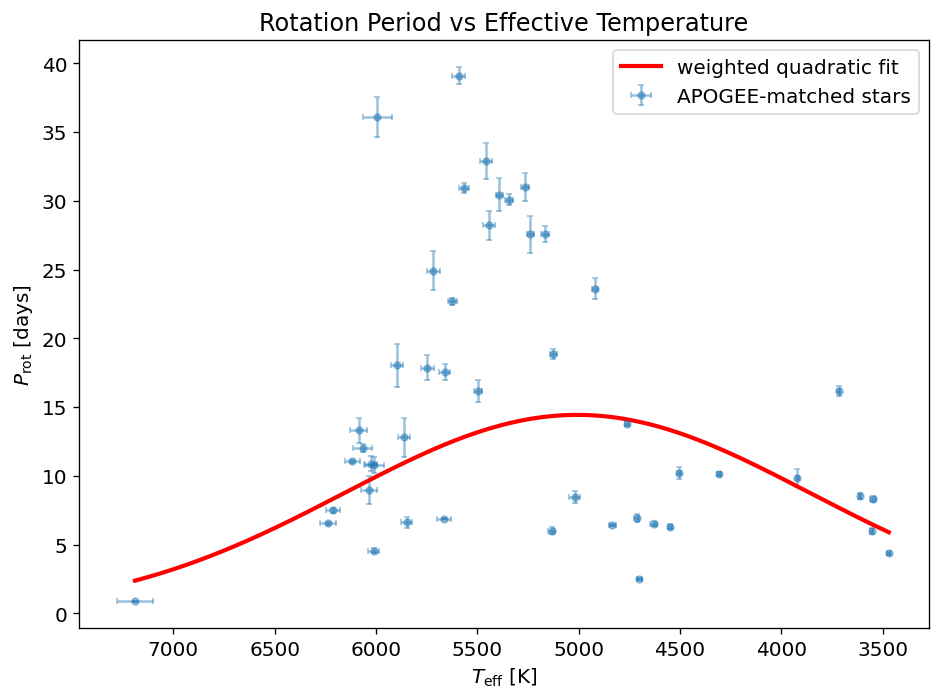

Fit:
log10(P_rot/days) = a x^2 + b x + c
x = (T_eff - 5500)/1000
a, b, c = [-0.16460318 -0.16247382  1.11929161]
1-sigma coefficient errors = [0.06383669 0.08101959 0.04619753]


In [49]:
fitP = apogee_sample[
    np.isfinite(apogee_sample["teff_apogee"]) &
    np.isfinite(apogee_sample["teff_err_apogee"]) &
    np.isfinite(apogee_sample["Prot_days"]) &
    np.isfinite(apogee_sample["Prot_err_days_lower"]) &
    (apogee_sample["Prot_days"] > 0) &
    (apogee_sample["Prot_err_days_lower"] > 0)
].copy()

x_teff = fitP["teff_apogee"].to_numpy()
x_scaled = (x_teff - 5500.0) / 1000.0

y_logP = np.log10(fitP["Prot_days"].to_numpy())
yerr_logP = fitP["Prot_err_days_lower"].to_numpy() / (
    fitP["Prot_days"].to_numpy() * np.log(10.0)
)

good = np.isfinite(x_scaled) & np.isfinite(y_logP) & np.isfinite(yerr_logP) & (yerr_logP > 0)

x_fit = x_scaled[good]
teff_fit = x_teff[good]
y_fit = y_logP[good]
yerr_fit = yerr_logP[good]

coef_P, cov_P = np.polyfit(x_fit, y_fit, deg=2, w=1.0 / yerr_fit, cov=True)
poly_P = np.poly1d(coef_P)

teff_grid = np.linspace(teff_fit.min(), teff_fit.max(), 500)
teff_grid_scaled = (teff_grid - 5500.0) / 1000.0
logP_grid = poly_P(teff_grid_scaled)

plt.figure(figsize=(8, 6))
plt.errorbar(
    teff_fit,
    10**y_fit,
    xerr=fitP.loc[good, "teff_err_apogee"].to_numpy(),
    yerr=fitP.loc[good, "Prot_err_days_lower"].to_numpy(),
    fmt="o",
    ms=4,
    alpha=0.45,
    capsize=2,
    linestyle="none",
    label="APOGEE-matched stars"
)

plt.plot(
    teff_grid,
    10**logP_grid,
    color="red",
    linewidth=2.5,
    label="weighted quadratic fit"
)

plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel(r"$P_{\rm rot}$ [days]")
plt.title("Rotation Period vs Effective Temperature")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

print("Fit:")
print(r"log10(P_rot/days) = a x^2 + b x + c")
print(r"x = (T_eff - 5500)/1000")
print("a, b, c =", coef_P)
print("1-sigma coefficient errors =", np.sqrt(np.diag(cov_P)))

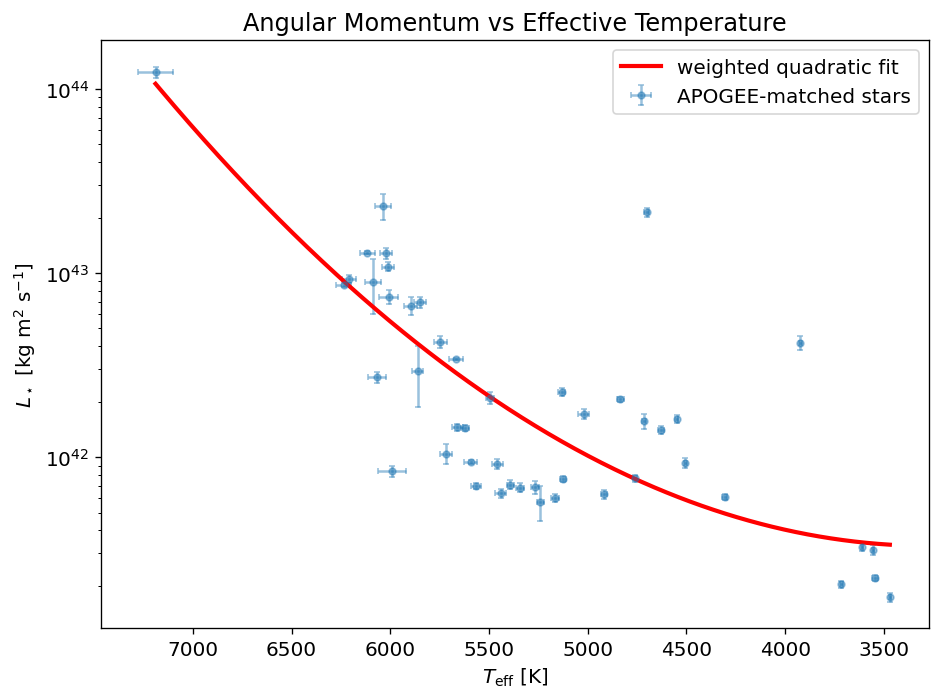

Fit:
log10(L_star) = a x^2 + b x + c
x = (T_eff - 5500)/1000
a, b, c = [ 0.16319219  0.72912943 42.33188676]
1-sigma coefficient errors = [0.06536874 0.09082104 0.05902744]


In [50]:
fitL = apogee_sample[
    np.isfinite(apogee_sample["teff_apogee"]) &
    np.isfinite(apogee_sample["teff_err_apogee"]) &
    np.isfinite(apogee_sample["Lstar"]) &
    np.isfinite(apogee_sample["L_err_lower"]) &
    (apogee_sample["Lstar"] > 0) &
    (apogee_sample["L_err_lower"] > 0)
].copy()

x_teff = fitL["teff_apogee"].to_numpy()
x_scaled = (x_teff - 5500.0) / 1000.0

y_logL = np.log10(fitL["Lstar"].to_numpy())
yerr_logL = fitL["L_err_lower"].to_numpy() / (
    fitL["Lstar"].to_numpy() * np.log(10.0)
)

good = np.isfinite(x_scaled) & np.isfinite(y_logL) & np.isfinite(yerr_logL) & (yerr_logL > 0)

x_fit = x_scaled[good]
teff_fit = x_teff[good]
y_fit = y_logL[good]
yerr_fit = yerr_logL[good]

coef_L, cov_L = np.polyfit(x_fit, y_fit, deg=2, w=1.0 / yerr_fit, cov=True)
poly_L = np.poly1d(coef_L)

teff_grid = np.linspace(teff_fit.min(), teff_fit.max(), 500)
teff_grid_scaled = (teff_grid - 5500.0) / 1000.0
logL_grid = poly_L(teff_grid_scaled)

plt.figure(figsize=(8, 6))
plt.errorbar(
    teff_fit,
    10**y_fit,
    xerr=fitL.loc[good, "teff_err_apogee"].to_numpy(),
    yerr=fitL.loc[good, "L_err_lower"].to_numpy(),
    fmt="o",
    ms=4,
    alpha=0.45,
    capsize=2,
    linestyle="none",
    label="APOGEE-matched stars"
)

plt.plot(
    teff_grid,
    10**logL_grid,
    color="red",
    linewidth=2.5,
    label="weighted quadratic fit"
)

plt.xlabel(r"$T_{\rm eff}$ [K]")
plt.ylabel(r"$L_\star$ [kg m$^2$ s$^{-1}$]")
plt.title("Angular Momentum vs Effective Temperature")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

print("Fit:")
print(r"log10(L_star) = a x^2 + b x + c")
print(r"x = (T_eff - 5500)/1000")
print("a, b, c =", coef_L)
print("1-sigma coefficient errors =", np.sqrt(np.diag(cov_L)))